In [9]:
import numpy as np 
import pandas as pd
import re 
import nltk 
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report 
import matplotlib.pyplot as plt 
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
df = pd.read_csv("Downloads/Restaurant_Reviews.tsv", delimiter="\t", quoting=3) 
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [20]:
print("First 5 rows:")
display(df.head()) 
print("\nDataset Shape:", df.shape) 
print("\nColumn Names:", df.columns)
print("\nDataset Information:")
df.info()
print("\nSentiment Distribution:") 
print(df["Liked"].value_counts())

First 5 rows:


,Review,Liked
0,The place here is terrible and not worth the m...,0
1,"What a great place, the bread exceeded expecta...",1
2,Such a bland experience with the food. The sal...,0
3,"Would not recommend, the bread was disappointing.",0
4,The chef here is noisy and not worth the money.,0



Dataset Shape: (12000, 2)

Column Names: Index(['Review', 'Liked'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  12000 non-null  object
 1   Liked   12000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 187.6+ KB

Sentiment Distribution:
Liked
0    6008
1    5992
Name: count, dtype: int64


In [22]:
nltk.download("stopwords")
print("Stopwords downloaded successfully!")

Stopwords downloaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kamal\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [23]:
corpus = [] 
ps = PorterStemmer() 
english_stopwords = set(stopwords.words("english"))  
for i in range(len(df)):    
    review = re.sub("[^a-zA-Z]", " ", df["Review"].iloc[i]).lower()   
    words = review.split()   
    words = [w for w in words if w not in english_stopwords]    
    words = [ps.stem(w) for w in words]    
    corpus.append(" ".join(words)) 
print("Preprocessing completed!")
print("\nFirst 10 processed reviews:") 
print(corpus[:10]) 

Preprocessing completed!

First 10 processed reviews:
['place terribl worth money restaur cold', 'great place bread exceed expect', 'bland experi food salad terribl', 'would recommend bread disappoint', 'chef noisi worth money', 'excel food great atmospher overal restaur tasti', 'hate cold steak dessert dirti', 'salad stale', 'cold bread poor atmospher overal pasta unfriendli', 'impress experi dessert']


In [26]:
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, 1].values
print("Feature matrix shape:", X.shape) 
print("Target shape:", y.shape)

Feature matrix shape: (12000, 90)
Target shape: (12000,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=0 )
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (9600, 90)
Testing data shape: (2400, 90)


In [30]:
model = RandomForestClassifier( n_estimators=35, random_state=42 ) 
model.fit(X_train, y_train) 
print("Random Forest model trained successfully!") 

Random Forest model trained successfully!


In [32]:
model_score = model.score(X_test, y_test) 
print("Model Accuracy:", round(model_score * 100, 2), "%")
y_pred = model.predict(X_test) 
print("Predictions completed!")

Model Accuracy: 100.0 %
Predictions completed!


In [33]:
score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred, zero_division=0) 
score3 = recall_score(y_test, y_pred, zero_division=0) 
print("---- Scores ----") 
print("Accuracy:", round(score1 * 100, 2), "%")
print("Precision:", round(score2, 2)) 
print("Recall:", round(score3, 2))

---- Scores ----
Accuracy: 100.0 %
Precision: 1.0
Recall: 1.0


In [34]:
print("Classification Report:")
print(classification_report( y_test, y_pred, zero_division=0 )) 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1184
           1       1.00      1.00      1.00      1216

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



Confusion Matrix:
[[1184    0]
 [   0 1216]]


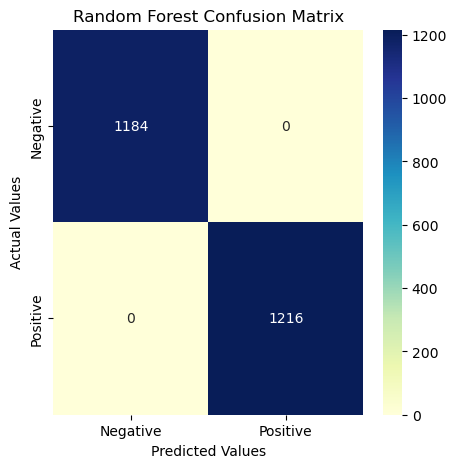

In [35]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(5, 5)) 
sns.heatmap( cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"] ) 
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Random Forest Confusion Matrix") 
plt.show()
 

In [39]:
best_accuracy = 0
n_estimators_val = 5 
print("Testing different n_estimators values...\n") 
for i in np.arange(1, 30, 2):
    temp_model = RandomForestClassifier( n_estimators=i,random_state=42)

    temp_model.fit(X_train, y_train)
    temp_pred = temp_model.predict(X_test) 
    score = accuracy_score(y_test, temp_pred)
    print( "n_estimators =", i, "Accuracy =", round(score * 100, 2), "%" )
    if score > best_accuracy:
        best_accuracy = score
        n_estimators_val = i 
        print( "Best accuracy:", round(best_accuracy * 100, 2), "%", "with n_estimators =", n_estimators_val ) 

Testing different n_estimators values...

n_estimators = 1 Accuracy = 99.79 %
Best accuracy: 99.79 % with n_estimators = 1
n_estimators = 3 Accuracy = 100.0 %
Best accuracy: 100.0 % with n_estimators = 3
n_estimators = 5 Accuracy = 100.0 %
n_estimators = 7 Accuracy = 100.0 %
n_estimators = 9 Accuracy = 100.0 %
n_estimators = 11 Accuracy = 100.0 %
n_estimators = 13 Accuracy = 100.0 %
n_estimators = 15 Accuracy = 100.0 %
n_estimators = 17 Accuracy = 100.0 %
n_estimators = 19 Accuracy = 100.0 %
n_estimators = 21 Accuracy = 100.0 %
n_estimators = 23 Accuracy = 100.0 %
n_estimators = 25 Accuracy = 100.0 %
n_estimators = 27 Accuracy = 100.0 %
n_estimators = 29 Accuracy = 100.0 %


In [ ]:
model = RandomForestClassifier( n_estimators=n_estimators_val, random_state=42 ) 
model.fit(X_train, y_train) 

In [40]:
print("Optimized Random Forest Model:")
print(model) 

Optimized Random Forest Model:
RandomForestClassifier(n_estimators=35, random_state=42)


In [41]:
def predict_sentiment(sample_review):
    review = re.sub("[^a-zA-Z]", " ", sample_review).lower()
    words = review.split() 
    words = [w for w in words if w not in english_stopwords] 
    words = [ps.stem(w) for w in words]
    review = " ".join(words) 
    data = cv.transform([review]).toarray()
    return model.predict(data)[0] 
sample_review = "The food is really good here."
prediction = predict_sentiment(sample_review) 
print("Review:", sample_review) 
if prediction == 1:
    print("This is a POSITIVE review.") 
else: print("This is a NEGATIVE review!")

Review: The food is really good here.
This is a NEGATIVE review!


In [44]:
sample_review = ( "The food was absolutely awful." ) 
prediction = predict_sentiment(sample_review)
print("Review:", sample_review) 
if prediction == 1: 
    print("This is a POSITIVE review.") 
else: 
    print("This is a NEGATIVE review!") 

Review: The food was absolutely awful.
This is a NEGATIVE review!


In [46]:
final_predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, final_predictions) 
precision = precision_score(y_test, final_predictions, zero_division=0) 
recall = recall_score(y_test, final_predictions, zero_division=0)
print("\n==========================================") 
print(" FINAL RANDOM FOREST MODEL PERFORMANCE") 
print("==========================================") 
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("Best n_estimators:", n_estimators_val)


 FINAL RANDOM FOREST MODEL PERFORMANCE
Accuracy : 100.0 %
Precision: 1.0
Recall   : 1.0
Best n_estimators: 3
